In [102]:
import numpy as np
import matplotlib.pyplot as plt
import numpy.random as random
from scipy.signal import convolve
import scipy
from joblib import Parallel, delayed
import time
import sys
from scipy import sparse
import json
from tqdm import tqdm, tqdm_notebook
import matplotlib.gridspec as gridspec
import os
from scipy import stats
from copy import deepcopy
sys.path.insert(0, "../Scripts")
# from antigenicWaveSimulationMethods import main as coEvoSimulation
from coverage import elementwise_coverage, coverage_1D
from fitness import fitness, norm_fitness, phage_growth
from altImmunity import immunity_loss_uniform, immunity_gain_from_kernel
from initMethods import init_trail_nh, init_1D_kernel, init_guassian_n, init_cond
from supMethods import time_conv, write2json, read_json
from mutation import mutation
from randomHGT import HGT_logistic_event
from formulas import gaussian1D, trail_exp

In [103]:
folder = "../Data_1D_Test_Np_1000"
params, sim_params = read_json(folder)

In [104]:
params["tau"]

34.67502565951899

In [105]:
x_lim = sim_params["xdomain"]
dx = sim_params["dx"]
x_range = np.arange(-x_lim, x_lim, dx)

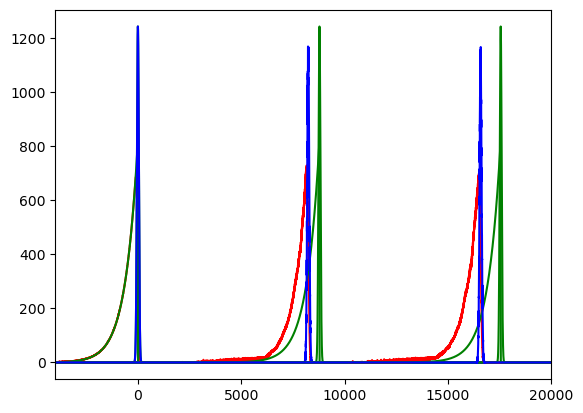

In [106]:
from formulas import trail_exp


for t in [0, 500, 999]:
    nh = np.load(folder + f"/frame_nh{t}.npy")
    n = np.load(folder + f"/frame_n{t}.npy")
    plt.plot(x_range, nh, color = "red")
    plt.plot(x_range, gaussian1D(x_range, t, params, sim_params), color = "green", label = "Theory")
    plt.plot(x_range, trail_exp(x_range, t, params, sim_params), color = "green", label = "Theory")
    plt.plot(x_range, n, color = "blue")

# plt.legend()
plt.xlim(-4000, 20000)
plt.show()

In [46]:
params["A"]

1

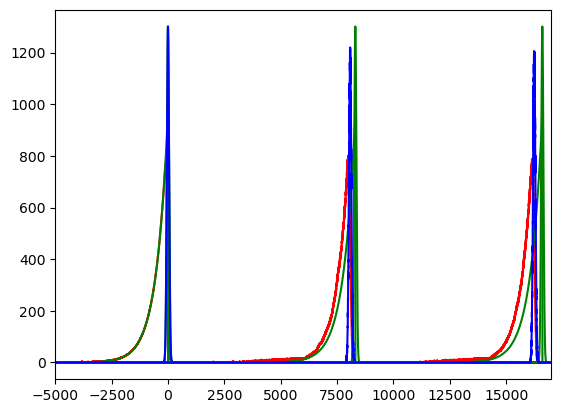

In [93]:
folder = "../Data_1D_Test_A_010"
params, sim_params = read_json(folder)

for t in [0, 500, 999]:
    nh = np.load(folder + f"/frame_nh{t}.npy")
    n = np.load(folder + f"/frame_n{t}.npy")
    plt.plot(x_range, nh, color = "red")
    plt.plot(x_range, gaussian1D(x_range, t, params, sim_params), color = "green", label = "Theory")
    plt.plot(x_range, trail_exp(x_range, t, params, sim_params), color = "green", label = "Theory")
    plt.plot(x_range, n, color = "blue")

# plt.legend()
plt.xlim(-5000, 17000)
# plt.legend()
plt.show()


In [95]:
import numpy as np
from scipy.optimize import curve_fit

def gaussian(x, a, x0, sigma):
    """Gaussian function."""
    normalization = 1/(sigma*np.sqrt(2*np.pi))
    return a *normalization*np.exp(-((x - x0) ** 2) / (2 * sigma ** 2))

def fit_gaussian(xdomain, data):
    """Fits a Gaussian to a 1D NumPy array and returns the optimal parameters.

    Args:
        data (np.array): The 1D array of data to fit.

    Returns:
        tuple: Optimal values for the amplitude (a), mean (x0), and standard deviation (sigma).
    """
    # Generate an x array that matches the indices of the data
    x = xdomain

    # Initial guesses for the parameters: amplitude (max of data), mean, and std deviation
    a_guess = np.max(data)
    x0_guess = np.sum(x * data) / np.sum(data)
    sigma_guess = np.sqrt(np.sum(data * (x - x0_guess) ** 2) / np.sum(data))

    # Fit the Gaussian model to the data
    popt, _ = curve_fit(gaussian, x, data, p0=[a_guess, x0_guess, sigma_guess])

    return popt

In [96]:
x_lim = sim_params["xdomain"]
dx = sim_params["dx"]
x_range = np.arange(-x_lim, x_lim, dx)

In [84]:
A_data = []
mean_data = []
error_data = []

for A in ["1", "05", "010", "1500", "2000"]:

    folder = "../Data_1D_Test_A_" + A
    params, sim_params = read_json(folder)
    A_data.append(params["A"])

    N_time = []
    var_time = []
    x_time = []

    for t in range(sim_params["tf"]):
        nh = np.load(folder + f"/frame_nh{t}.npy")
        n = np.load(folder + f"/frame_n{t}.npy")
        popt = fit_gaussian(x_range, n)
        N_time.append(popt[0])
        var_time.append(popt[2])
        x_time.append(popt[1])

    velocity = np.diff(x_time)
    means = [np.mean(N_time), np.mean(var_time), np.mean(velocity)]
    mean_data.append(means)

    errors = [np.std(N_time), np.std(var_time), np.std(velocity)]
    error_data.append(errors)

A_data = np.array(A_data)
mean_data = np.array(mean_data)
error_data = np.array(error_data)

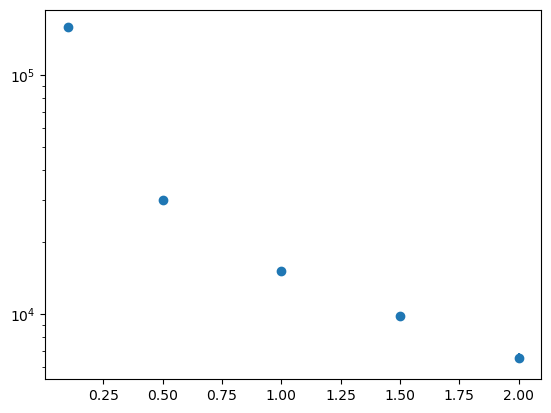

In [86]:
plt.errorbar(A_data, mean_data[:, 0], yerr = error_data[:, 0], fmt = 'o')
plt.yscale("log")
plt.show()

(7800.0, 8500.0)

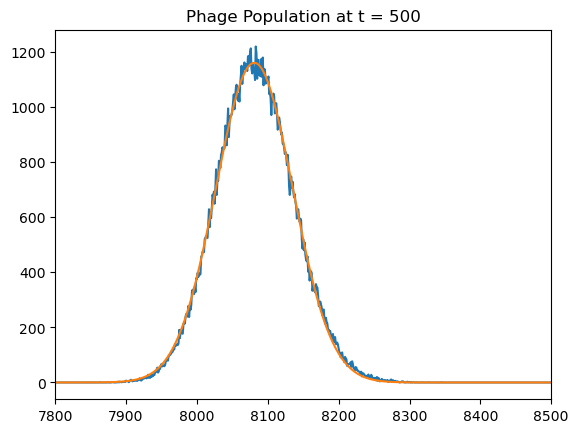

In [101]:

folder = "../Data_1D_Test_A_" + "010"
# params, sim_params = read_json(folder)
# A_data.append(params["A"])
# for t in range(sim_params["tf"]):
n = np.load(folder + f"/frame_n{500}.npy")
popt = fit_gaussian(x_range, n)


plt.plot(x_range, n)
plt.plot(x_range, gaussian(x_range, *popt))
plt.title("Phage Population at t = 500")
plt.xlim(7800, 8500)

In [71]:
popt

array([ 6048.72918863, 15505.12859394,    58.00772039])

In [54]:
params0 = { #parameters relevant for the equations
        "Nh":                     1E5,
        "N0":                     1E9, #This Will be updated by self-consitent solution
        "R0":                      20, 
        "M":                        5, #Also L, total number of spacers
        "mu":                      50, #mutation rate
        "gamma_shape":             20,
        "Np":                      10, #Number of Cas Protein
        "dc":                      10, #Required number of complexes to activate defence
        "h":                       10, #coordination coeff
        "r":                     1000, #cross-reactivity kernel
        "beta":                     0,
        "rate_HGT":                 0,
        "HGT_bonus_acq_ratio":      0,
        "rate_recovery":            0,
        "HGT_type":                 0,
        "n_spacer":                 1,
        "A":                        2,
    }
sim_params0 = { #parameters relevant for the simulation (including Inital Valuess)
        "continue":                 False, #DO NOT CREATE ARBITRARY FOLDERS ONLY FOR TESTS
        "xdomain":                  50000,
        "dim":                          1,
        "dx":                           1,
        "tf":                        1000,
        "dt":                           1,
        "dt_exact_fitness":             1,
        "dt_snapshot":                  1,
        "initial_mean_n":           [0,0],
        "initial_mean_nh":          [0,0],
        "conv_size":                 2000,
        "num_threads":                 32,
        "foldername":   "../Data_1D_Test_A_2000",
        "seed":                         34,
        "hard_N0":                   False,
        "ndim":                         1,
    }

In [77]:
A_range = np.power(10, np.arange(-3, 1, 0.1))
N_theory = []
sigma_theory = []
v_theory = []

for A in A_range:
    params = deepcopy(params0)
    sim_params = deepcopy(sim_params0)

    params["A"] = A
    params, sim_params = init_cond(params, sim_params)

    N_theory.append(params["N"])
    sigma_theory.append(params["sigma"])
    v_theory.append(params["v0"])

Assumptions Checks: 
mu >> 1 : mu = 50 >> 1
del_x << r : gamma_shape = 20 << r = 1000
v*tau >> sigma : v*tau = 521.1246536102815 >> sigma = 52.16693813147669
uc << r : uc = 245.14493096066823 << r = 1000
Assumptions Checks: 
mu >> 1 : mu = 50 >> 1
del_x << r : gamma_shape = 20 << r = 1000
v*tau >> sigma : v*tau = 521.1246536102815 >> sigma = 52.02683792083264
uc << r : uc = 242.52206293392177 << r = 1000
Assumptions Checks: 
mu >> 1 : mu = 50 >> 1
del_x << r : gamma_shape = 20 << r = 1000
v*tau >> sigma : v*tau = 521.1246536102815 >> sigma = 51.88477073853601
uc << r : uc = 239.88392003191223 << r = 1000
Assumptions Checks: 
mu >> 1 : mu = 50 >> 1
del_x << r : gamma_shape = 20 << r = 1000
v*tau >> sigma : v*tau = 521.1246536102815 >> sigma = 51.740674016835825
uc << r : uc = 237.23013526999677 << r = 1000
Assumptions Checks: 
mu >> 1 : mu = 50 >> 1
del_x << r : gamma_shape = 20 << r = 1000
v*tau >> sigma : v*tau = 521.1246536102815 >> sigma = 51.59448198923019
uc << r : uc = 234.560325

In [62]:
params["Nh"]*params["M"]

500000.0

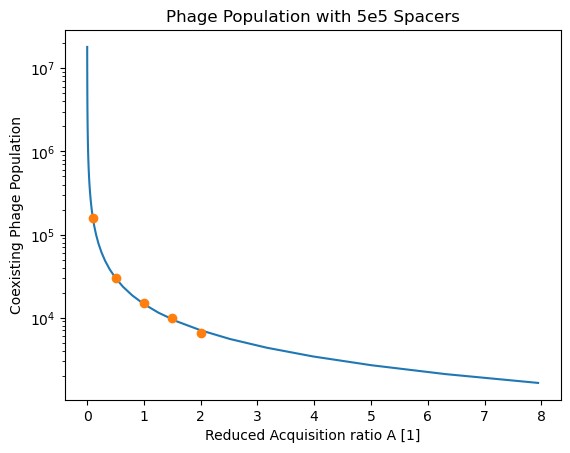

In [63]:
plt.plot(A_range, N_theory)
plt.errorbar(A_data, mean_data[:, 0], yerr = error_data[:, 0], fmt = 'o')
plt.title("Phage Population with 5e5 Spacers")
plt.xlabel("Reduced Acquisition ratio A [1]")
plt.ylabel("Coexisting Phage Population")
plt.yscale("log")
plt.show()

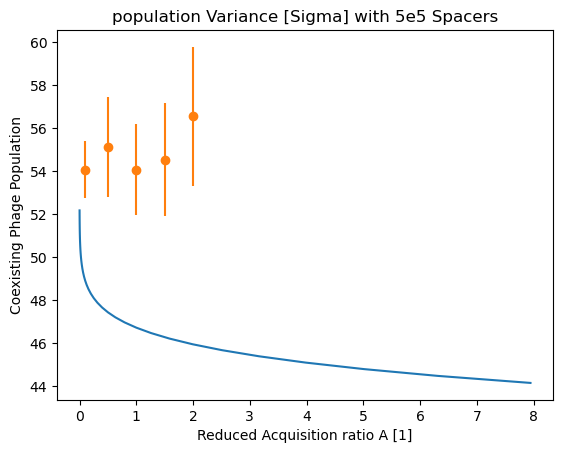

In [87]:
plt.plot(A_range, sigma_theory)
plt.errorbar(A_data, mean_data[:, 1], yerr = error_data[:, 1], fmt = 'o')
plt.title("population Variance [Sigma] with 5e5 Spacers")
plt.xlabel("Reduced Acquisition ratio A [1]")
plt.ylabel("Coexisting Phage Population")
# plt.yscale("log")
plt.show()

In [74]:
A_data = []
mean_data = []
error_data = []

for A in ["1", "05", "010", "1500", "2000"]:

    folder = "../Data_1D_Test_A_" + A
    params, sim_params = read_json(folder)
    print(params["sigma"])

46.71690872149097
47.4309568348259
48.90013409961371
46.27097785180777
45.94012550314259


In [67]:
mean_data[:, 2]

array([0.0035556 , 0.0114399 , 0.00446816, 0.00861624, 0.01205399])

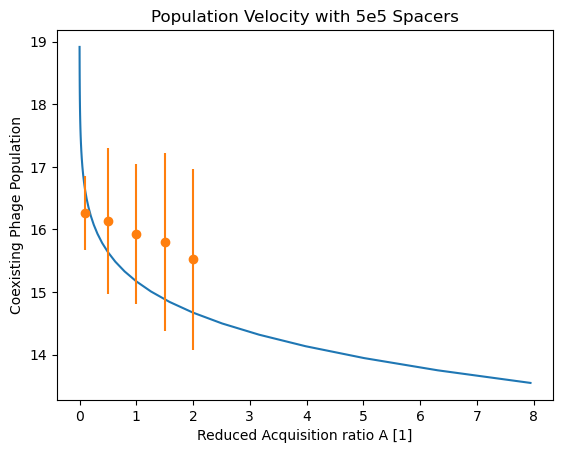

In [89]:
plt.plot(A_range, v_theory)
plt.errorbar(A_data, mean_data[:, 2], yerr = error_data[:, 2], fmt = 'o')
plt.title("Population Velocity with 5e5 Spacers")
plt.xlabel("Reduced Acquisition ratio A [1]")
plt.ylabel("Coexisting Phage Population")
# plt.yscale("log")
plt.show()